# trackastra 080926 — summary statistics

Postprocessing and figures for `data/all_data_080926.csv`, the combined trackastra output
built by `08_build_combined_data.py`. Visually QC'd against `data/kymograph_viewer_080726.html`.


In [88]:
import os
import sys

REPO_ROOT = '/Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker'
sys.path.insert(0, REPO_ROOT)          # belt-and-braces; mmtrack is also pip-installed -e
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mmtrack, pandas, matplotlib
assert os.path.realpath(mmtrack.__file__).startswith(os.path.realpath(REPO_ROOT)), (
    f'mmtrack resolves to {mmtrack.__file__}, not this repo.\n'
    f'Fix with:  {sys.executable} -m pip install -e . --no-deps   (run from {REPO_ROOT})'
)

from mmtrack.experiment_metadata import STRAIN_EXP_DICT   # fails loudly if stale
print('genes in experiment_metadata:', len(STRAIN_EXP_DICT))

genes in experiment_metadata: 10


## Environment check

Run this before anything else. A wrong interpreter or a shadowed `mmtrack` shows up here as a
clear error instead of surfacing later as "some data isn't loading".

`mmtrack` must resolve **inside this repo**. The `mmct` env previously had an editable install
pointing at `Covert_lab/Repos/Image_analysis`, a stale copy with no `experiment_metadata.py`;
`from mmtrack.experiment_metadata import ...` then failed depending on cell execution order.
Repaired with `pip install -e . --no-deps` from the repo root, which this cell re-verifies.

In [89]:

print('python     ', sys.executable)
print('mmtrack    ', mmtrack.__file__)
print('pandas     ', pandas.__version__, '| matplotlib', matplotlib.__version__)

# Re-import edited modules before each cell. This notebook is developed alongside the
# mmtrack modules it imports, and Python caches modules in sys.modules -- without this,
# adding an argument to e.g. plot_dy_histogram and re-running the cell still calls the
# OLD function and raises "unexpected keyword argument".
# Caveat: this only helps from here on. If a signature changed BEFORE autoreload was
# loaded in this kernel, the stale object is already bound and you must restart.
%load_ext autoreload
%autoreload 2

python      /opt/miniconda3/envs/mmct/bin/python
mmtrack     /Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/mmtrack/__init__.py
pandas      2.3.3 | matplotlib 3.10.6
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## CONFIG

The only cell you edit. `None` means "no filter".

In [90]:
# REPO_ROOT is defined in the imports cell above.

#paths 
CSV_PATH       = f'{REPO_ROOT}/data/all_data_080926.csv'
TIME_DICT_PATH = f'{REPO_ROOT}/data/time_dict_080726.json'
PAIRS_CSV      = f'{REPO_ROOT}/data/track_pairs_080926.csv'   # from 07_track_displacement_analysis.py
BASE_DIR       = '/Volumes/mcovert/Instruments/Covert-lab-scope1/subgen_processed_data'
TRACKASTRA_DIR = '/Volumes/mcovert/Instruments/Covert-lab-scope1/track_test/track_astra_output'
PHASE_C, FLUOR_C = '0', '1'
FIG_DIR        = f'{REPO_ROOT}/notebooks/figures/summary_080926'


#experiment info
GENE        = None    
EXPERIMENTS = None    
FOVS        = None    
MIN_TRACK_FRAMES = 1  # drop tracks observed in fewer than this many frames; 1 = keep all 

SAVE_FIGS = True      

pd.set_option('display.max_rows', 300)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', None)   # peak_ids lists must not be truncated

## Load

`coords` is a stringified array and accounts for ~95% of the 277 MB file, so it is excluded
via `usecols` — the same trick as `mmtrack.track_displacement.load_cell_data`. Load drops from
about a minute to under a second.

`FOV` and `trench_id` are read as **strings**. A bare `read_csv` infers `FOV` as int64 and
turns `'015'` into `15`, which then no longer matches the zero-padded FOV keys in
`mmtrack.experiment_metadata` or the card ids in the kymograph viewer HTML.

In [91]:
KYMO_KEY = ['experiment_name', 'FOV', 'trench_id']   # one kymograph / peak_id
CELL_KEY = KYMO_KEY + ['track_id']                   # one unique cell

SUMMARY_COLS = [
    'gene', 'experiment_name', 'FOV', 'trench_id', 'track_id',
    'parent_track_id', 'predicted_lineage', 'time_frame', 'time_min',
    'minutes_per_frame', 'phase_exposure_ms', 'fluor_exposure_ms',
    'area', 'intensity_mean_fluor',
]


def load_summary_data(csv_path=CSV_PATH):
    """Load the combined trackastra table without the huge `coords` column."""
    df = pd.read_csv(
        csv_path,
        usecols=lambda c: c in SUMMARY_COLS,
        dtype={'FOV': str, 'trench_id': str, 'experiment_name': str, 'gene': str},
    )
    df['FOV'] = df['FOV'].str.zfill(3)
    missing = [c for c in SUMMARY_COLS if c not in df.columns]
    if missing:
        print(f'NOTE: columns absent from this CSV: {missing}')
    return df


def describe_scope(df, label='loaded'):
    n_kymo = len(df[KYMO_KEY].drop_duplicates())
    n_cell = len(df[CELL_KEY].drop_duplicates())
    print(f'{label}: {len(df):,} rows | {df.experiment_name.nunique()} experiments | '
          f'{df.gene.nunique()} genes | {n_kymo:,} kymographs | {n_cell:,} unique cells')


all_data = load_summary_data()
describe_scope(all_data)


loaded: 89,041 rows | 22 experiments | 10 genes | 287 kymographs | 12,542 unique cells


In [92]:
def track_frame_counts(df):
    """Frames observed per unique cell."""
    return df.groupby(CELL_KEY, observed=True)['time_frame'].nunique()


def scope(df, gene=None, experiments=None, fovs=None, min_frames=1):
    """Apply the CONFIG filters. Everything below runs on the result."""
    out = df
    if gene is not None:
        out = out[out['gene'].isin([gene] if isinstance(gene, str) else list(gene))]
    if experiments is not None:
        exps = [experiments] if isinstance(experiments, str) else list(experiments)
        out = out[out['experiment_name'].isin(exps)]
    if fovs is not None:
        f = [fovs] if isinstance(fovs, str) else list(fovs)
        out = out[out['FOV'].isin([str(x).zfill(3) for x in f])]
    out = out.copy()
    if min_frames and min_frames > 1:
        n = track_frame_counts(out)
        keep = n[n >= min_frames].index
        idx = out.set_index(CELL_KEY)
        out = idx[idx.index.isin(keep)].reset_index()
    return out


def scope_label(gene=None, experiments=None, fovs=None, min_frames=1):
    """Human-readable tag for figure titles."""
    bits = [gene if isinstance(gene, str)
            else ('all genes' if gene is None else '+'.join(gene))]
    if experiments is not None:
        exps = [experiments] if isinstance(experiments, str) else list(experiments)
        bits.append(exps[0] if len(exps) == 1 else f'{len(exps)} experiments')
    if fovs is not None:
        f = [fovs] if isinstance(fovs, str) else list(fovs)
        bits.append('FOV ' + ','.join(str(x).zfill(3) for x in f))
    if min_frames and min_frames > 1:
        bits.append(f'tracks ≥{min_frames} frames')
    return ' | '.join(bits)


def scope_suffix(gene=None, experiments=None, fovs=None, min_frames=1):
    """Filename suffix, so a re-run under a different scope does not overwrite files."""
    bits = []
    if gene is not None:
        bits.append(gene if isinstance(gene, str) else '-'.join(gene))
    if experiments is not None:
        exps = [experiments] if isinstance(experiments, str) else list(experiments)
        bits.append(exps[0] if len(exps) == 1 else f'{len(exps)}exp')
    if fovs is not None:
        f = [fovs] if isinstance(fovs, str) else list(fovs)
        bits.append('fov' + '-'.join(str(x).zfill(3) for x in f))
    if min_frames and min_frames > 1:
        bits.append(f'min{min_frames}')
    return ('_' + '_'.join(bits)) if bits else ''


df     = scope(all_data, GENE, EXPERIMENTS, FOVS, MIN_TRACK_FRAMES)
LABEL  = scope_label(GENE, EXPERIMENTS, FOVS, MIN_TRACK_FRAMES)
SUFFIX = scope_suffix(GENE, EXPERIMENTS, FOVS, MIN_TRACK_FRAMES)
describe_scope(df, f'scoped [{LABEL}]')

scoped [all genes]: 89,041 rows | 22 experiments | 10 genes | 287 kymographs | 12,542 unique cells


## Table A — per gene

How many experiments, FOVs, kymographs and unique cells each gene contributes.

- `n_singleton` / `pct_singleton` — tracks seen in exactly one frame. These are kept in
  `n_unique_cells`; they are the most likely segmentation noise, so treat the pair as a data
  quality readout. Raise `MIN_TRACK_FRAMES` to exclude them.
- `cell_hours` uses each experiment's own `minutes_per_frame` — the set mixes 5 and 10 min
  intervals, so summing frames alone would be wrong.
- The `TOTAL` row is recomputed from the whole frame rather than summed: several experiments
  hold two genes in different FOVs, so summing `n_experiments` would double-count them.

In [93]:
def summarize_by_gene(df):
    cells = df[CELL_KEY + ['gene']].drop_duplicates()
    kymos = df[KYMO_KEY + ['gene']].drop_duplicates()
    fovs  = df[['gene', 'experiment_name', 'FOV']].drop_duplicates()

    n_frames = track_frame_counts(df).rename('n_frames').reset_index()
    n_frames = n_frames.merge(cells, on=CELL_KEY, how='left')

    cells_per_kymo = (cells.groupby(KYMO_KEY, observed=True).size().rename('n')
                      .reset_index().merge(kymos, on=KYMO_KEY, how='left'))

    out = pd.DataFrame({
        'n_experiments':          df.groupby('gene')['experiment_name'].nunique(),
        'n_FOVs':                 fovs.groupby('gene').size(),
        'n_kymographs':           kymos.groupby('gene').size(),
        'n_unique_cells':         cells.groupby('gene').size(),
        'n_singleton':            n_frames[n_frames.n_frames == 1].groupby('gene').size(),
        'median_cells_per_kymo':  cells_per_kymo.groupby('gene')['n'].median(),
        'median_track_frames':    n_frames.groupby('gene')['n_frames'].median(),
        'max_track_frames':       n_frames.groupby('gene')['n_frames'].max(),
        'n_rows':                 df.groupby('gene').size(),
        'cell_hours':             (df['minutes_per_frame'] / 60).groupby(df['gene']).sum(),
    })
    out['n_singleton'] = out['n_singleton'].fillna(0).astype(int)
    out = out.sort_values('n_unique_cells', ascending=False)

    all_frames = track_frame_counts(df)
    out.loc['TOTAL'] = {
        'n_experiments':         df['experiment_name'].nunique(),
        'n_FOVs':                len(df[['experiment_name', 'FOV']].drop_duplicates()),
        'n_kymographs':          len(df[KYMO_KEY].drop_duplicates()),
        'n_unique_cells':        len(df[CELL_KEY].drop_duplicates()),
        'n_singleton':           int((all_frames == 1).sum()),
        'median_cells_per_kymo': cells_per_kymo['n'].median(),
        'median_track_frames':   all_frames.median(),
        'max_track_frames':      all_frames.max(),
        'n_rows':                len(df),
        'cell_hours':            (df['minutes_per_frame'] / 60).sum(),
    }

    counts = ['n_experiments', 'n_FOVs', 'n_kymographs', 'n_unique_cells',
              'n_singleton', 'max_track_frames', 'n_rows']
    out[counts] = out[counts].astype(int)
    out['pct_singleton'] = (100 * out['n_singleton'] / out['n_unique_cells']).round(1)
    out['cell_hours'] = out['cell_hours'].round(1)
    return out[['n_experiments', 'n_FOVs', 'n_kymographs', 'n_unique_cells',
                'n_singleton', 'pct_singleton', 'median_cells_per_kymo',
                'median_track_frames', 'max_track_frames', 'n_rows', 'cell_hours']]


gene_summary = summarize_by_gene(df)
print(gene_summary.to_string())

       n_experiments  n_FOVs  n_kymographs  n_unique_cells  n_singleton  pct_singleton  median_cells_per_kymo  median_track_frames  max_track_frames  n_rows  cell_hours
gene                                                                                                                                                                    
baeS               3      11            53            2673          276           10.3                   52.0                  6.0                67   18255      2972.2
araB               3      13            56            2240          308           13.8                   35.5                  6.0                53   14156      2359.3
gfcE               4      11            45            1911          229           12.0                   32.0                  6.0                57   13915      1788.1
lacZ               3       4            23            1483          140            9.4                   69.0                  7.0                44   1193

In [94]:
def peaks_per_fov(df):
    keys  = ['gene', 'experiment_name', 'FOV']
    kymos = df[KYMO_KEY + ['gene']].drop_duplicates()
    cells = df[CELL_KEY + ['gene']].drop_duplicates()
    return pd.DataFrame({
        'n_peaks':  kymos.groupby(keys).size(),
        'n_cells':  cells.groupby(keys).size(),
        'peak_ids': kymos.groupby(keys)['trench_id'].apply(
            lambda s: ', '.join(sorted(s, key=int))),
    }).sort_index()


peak_inventory = peaks_per_fov(df)
_w = peak_inventory['peak_ids'].str.len().max()


## Figures

House style follows `mmtrack/track_displacement.py:263-278` — transparent SVG plus 200 dpi
PNG, top and right spines hidden. Gene colors are assigned from the **full** dataset, not the
scoped one, so a gene keeps the same color when you re-run with `GENE` set to a single strain.

In [95]:
def _style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def _save(fig, name, out_dir=FIG_DIR, save=SAVE_FIGS):
    """SVG + PNG pair. Unlike the track_displacement version this does not close the
    figure, so it still renders inline."""
    if not save:
        return None
    os.makedirs(out_dir, exist_ok=True)
    fig.savefig(f'{out_dir}/{name}.svg', transparent=True, bbox_inches='tight')
    fig.savefig(f'{out_dir}/{name}.png', dpi=200, bbox_inches='tight')
    return f'{out_dir}/{name}.svg'


ALL_GENES = sorted(all_data['gene'].dropna().unique())

# Fixed gene -> tab10 colour. Pinned explicitly rather than derived from the data: a
# positional map silently reassigns every colour when a gene is added, dropped, or the
# frame is scoped to a subset. Ten genes, ten tab10 slots.
GENE_COLOR = {
    'alkA': '#1f77b4',   # blue
    'araB': '#ff7f0e',   # orange
    'baeS': '#2ca02c',   # green
    'chpS': '#d62728',   # red
    'gfcE': '#9467bd',   # purple
    'gldA': '#8c564b',   # brown
    'hupA': '#e377c2',   # pink
    'lacZ': '#7f7f7f',   # gray
    'mazF': '#bcbd22',   # olive
    'murQ': '#17becf',   # cyan
}

_unmapped = {}


def gene_color(gene):
    """Colour for a gene. A new strain should be added to GENE_COLOR deliberately, so
    anything unmapped gets a tab20 fallback and says so once rather than silently
    borrowing another gene's colour."""
    if gene in GENE_COLOR:
        return GENE_COLOR[gene]
    if gene not in _unmapped:
        _unmapped[gene] = plt.get_cmap('tab20')(len(_unmapped) % 20)
        print(f'NOTE: {gene!r} is not in GENE_COLOR; using a tab20 fallback. '
              f'Add it to the map to pin its colour.')
    return _unmapped[gene]


def _shades(base, n):
    """n tints of `base`, dark -> light. Splits a gene's bar by experiment."""
    rgb = np.array(mcolors.to_rgb(base))
    factors = [0.0] if n == 1 else np.linspace(0.0, 0.6, n)
    return [tuple(rgb * (1 - f) + f) for f in factors]


def _label_color(rgb):
    """White on dark fills, dark grey on light ones."""
    r, g, b = mcolors.to_rgb(rgb)
    return 'white' if (0.299 * r + 0.587 * g + 0.114 * b) < 0.55 else '0.2'

### Figure 1 — unique cells per gene, split by experiment

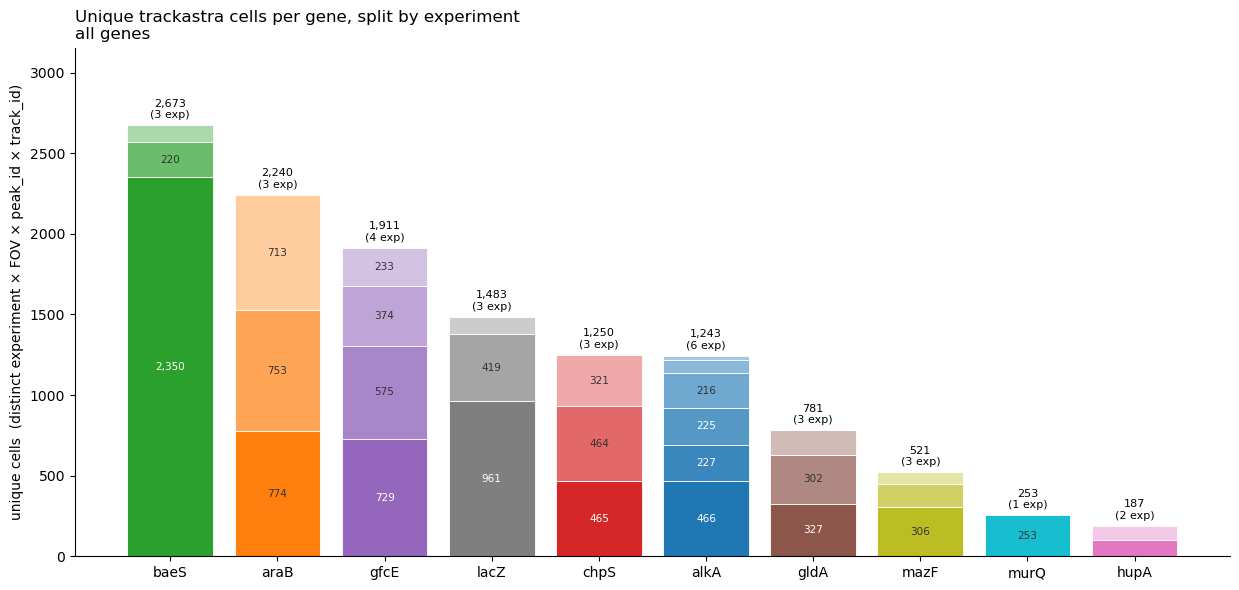

In [96]:
def fig_cells_per_gene(df, label=None, suffix=None):
    # resolved at call time, not def time, so re-running just the CONFIG cell is enough
    label = LABEL if label is None else label
    suffix = SUFFIX if suffix is None else suffix
    cells   = df[CELL_KEY + ['gene']].drop_duplicates()
    per_exp = cells.groupby(['gene', 'experiment_name']).size()
    # descending: with genes on x, largest reads left-to-right
    totals  = per_exp.groupby('gene').sum().sort_values(ascending=False)
    genes   = list(totals.index)

    fig, ax = plt.subplots(figsize=(0.95 * len(genes) + 3, 6))
    for x, gene in enumerate(genes):
        segs   = per_exp[gene].sort_values(ascending=False)
        colors = _shades(gene_color(gene), len(segs))
        bottom = 0                      # the stacking offset; `left=` when horizontal
        for (exp, n), c in zip(segs.items(), colors):
            ax.bar(x, n, bottom=bottom, color=c, edgecolor='white', linewidth=0.6)
            if n > 0.06 * totals.max():
                ax.text(x, bottom + n / 2, f'{n:,}', ha='center', va='center',
                        fontsize=7.5, color=_label_color(c))
            bottom += n
        ax.text(x, bottom + 0.012 * totals.max(),
                f'{totals[gene]:,}\n({len(segs)} exp)',
                ha='center', va='bottom', fontsize=8)

    ax.set_xticks(range(len(genes)), genes)
    ax.set_ylim(0, totals.max() * 1.18)
    ax.set_ylabel('unique cells  (distinct experiment × FOV × peak_id × track_id)')
    ax.set_title(f'Unique trackastra cells per gene, split by experiment\n{label}', loc='left')
    _style(ax)
    fig.tight_layout()
    _save(fig, f'cells_per_gene{suffix}')
    return fig


fig_cells_per_gene(df);

---
# Δy displacement QC

Regenerated from `data/all_data_080926.csv` by stage 7:

```bash
poetry run python 07_track_displacement_analysis.py --gene all \
    --pairs-csv data/track_pairs_080926.csv --fluor-method none
```

Each track is broken into consecutive-frame pairs (**within** a `track_id` only — a daughter's
first frame against the parent's last is a real jump, not an error).

### The criterion: one cell length

A pair is flagged when
$$|\Delta y| > 1.0 \times \text{cell length}$$
where cell length is the mean `axis_major_length` of the two endpoints (median 36.3 px). The
reasoning is physical: a tracking error means the track landed on a **different** cell, and in a
trench of stacked cells that takes roughly one cell length of apparent motion. The data agrees —
`|Δy| / cell_length` falls monotonically to a floor at ~1.0 and then flattens into a long tail
out to 43×, so the threshold sits in the valley between advection and hops. **1,470 of 76,499
pairs (1.92%)** are flagged.

`delta_fluor` differences `intensity_mean_fluor` straight from the CSV (`--fluor-method none`,
no image I/O). `fluor_zscore` / `is_significant` are defined on good pairs only; jump rows carry
NaN / False.

Other modes remain available: `--dy-abs-cutoff <px>` for a fixed pixel cutoff, or
`--dy-length-k 0` to fall back to the robust-MAD window.

In [97]:
PAIR_DTYPES = {'FOV': str, 'trench_id': str, 'experiment_name': str, 'gene': str}

pairs_all = pd.read_csv(PAIRS_CSV, dtype=PAIR_DTYPES)
pairs_all['FOV'] = pairs_all['FOV'].str.zfill(3)

# The threshold is per-row, so the bound is a constant in cell-length units rather than
# something to recover from the data.
DY_LENGTH_K = 1.0
DY_BOUNDS = (-DY_LENGTH_K, DY_LENGTH_K)
DY_UNITS = 'cell_lengths'


### Scope the pairs to the CONFIG selection

In [98]:
def scope_pairs(pairs, gene=None, experiments=None, fovs=None):
    # Same filters as scope(). MIN_TRACK_FRAMES is not applied: a pair already implies a
    # track of at least two frames.
    out = pairs
    if gene is not None:
        out = out[out['gene'].isin([gene] if isinstance(gene, str) else list(gene))]
    if experiments is not None:
        exps = [experiments] if isinstance(experiments, str) else list(experiments)
        out = out[out['experiment_name'].isin(exps)]
    if fovs is not None:
        f = [fovs] if isinstance(fovs, str) else list(fovs)
        out = out[out['FOV'].isin([str(x).zfill(3) for x in f])]
    return out.copy()


pairs = scope_pairs(pairs_all, GENE, EXPERIMENTS, FOVS)
good  = pairs[~pairs['is_jump']]
print(f'scoped [{LABEL}]: {len(pairs):,} pairs | {pairs.is_jump.sum():,} jumps '
      f'({100*pairs.is_jump.mean():.2f}%) | {len(good):,} good | '
      f'{int(pairs.is_significant.sum()):,} significant Δfluor')

scoped [all genes]: 76,499 pairs | 1,470 jumps (1.92%) | 75,029 good | 3,370 significant Δfluor


### Per-experiment diagnostic

`robust_sd_px` is the spread the **old** pixel cutoff keyed on — it tracks the acquisition
interval, and sorting by it puts every 5-min experiment below every 10-min one. `flag_pct` is
the rate under the cell-length criterion actually in use. The two columns together show what the
switch bought: the interval-driven ordering in `robust_sd_px` no longer sets the flag rate,
though a real residual spread remains.

In [99]:
from mmtrack.track_displacement import _robust_center_scale

def dy_by_experiment(pairs):
    rows = []
    for (mins, gene, exp), s in pairs.groupby(
            ['minutes_per_frame', 'gene', 'experiment_name'], sort=False):
        med, sd = _robust_center_scale(s['delta_y'])
        rows.append({
            'min_per_frame': mins, 'gene': gene, 'experiment_name': exp,
            'n_pairs': len(s),
            'median_dy_px': round(med, 2), 'robust_sd_px': round(sd, 2),
            'median_cell_len': round(s['cell_length'].median(), 1),
            'median_abs_dy_cl': round(s['delta_y_cell_lengths'].abs().median(), 3),
            'flag_pct': round(100 * s['is_jump'].mean(), 2),
        })
    return pd.DataFrame(rows).sort_values('robust_sd_px').reset_index(drop=True)


dy_diag = dy_by_experiment(pairs)
print(f'Per-experiment Δy  [{LABEL}]   applied cutoff: |Δy| > {DY_LENGTH_K}× cell length\n')
print(dy_diag.to_string(index=False))
print()
print('by acquisition interval:')
print(dy_diag.groupby('min_per_frame')
      .agg(n_experiments=('experiment_name', 'size'),
           median_robust_sd_px=('robust_sd_px', 'median'),
           median_flag_pct=('flag_pct', 'median')).to_string())

Per-experiment Δy  [all genes]   applied cutoff: |Δy| > 1.0× cell length

 min_per_frame gene                   experiment_name  n_pairs  median_dy_px  robust_sd_px  median_cell_len  median_abs_dy_cl  flag_pct
             5 baeS        DUMM_giTG66_Glucose_012325      741         -0.69          1.90             12.8             0.115      5.13
             5 chpS        DUMM_giTG62_Glucose_012925     4306         -3.57          4.60             37.4             0.105      1.18
             5 hupA               DUMM_giTG068_052925      951         -3.70          4.61             46.1             0.090      0.32
             5 lacZ DUMM_giTG059_noKan_Glucose_031125     3524         -5.31          5.82             38.3             0.162      0.91
             5 gldA        DUMM_giTG69_Glucose_013025     2671         -5.27          6.15             38.5             0.153      0.86
            10 gldA           DUMM_giTG069_063_121125     1702         -3.79          6.15             39.2   

### Figures

Drawn with the repo's own plot functions from `mmtrack.track_displacement`, passing
`close=False` so they render inline instead of being closed straight after saving. `units`
puts the Δy axis in the same units as the threshold, so the cutoff lines sit at ±1.0.

/Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/notebooks/figures/summary_080926/dy_delta_y_hist.svg
/Users/adrianjuarez/Documents/Covert_lab/repos/mother_machine_cell_tracker/notebooks/figures/summary_080926/dy_delta_fluor_hist.svg


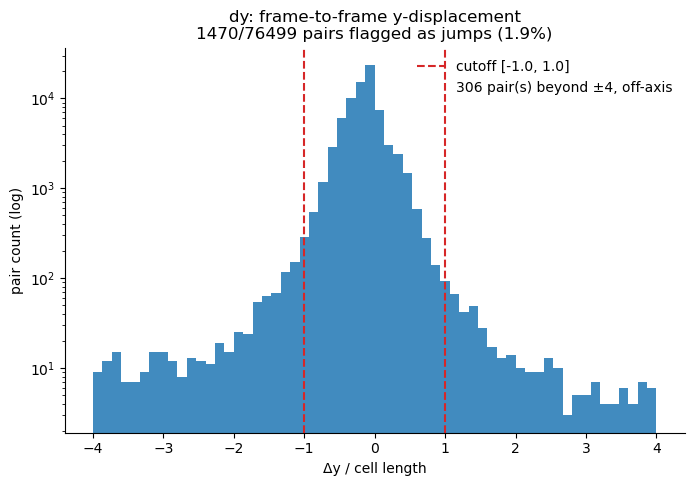

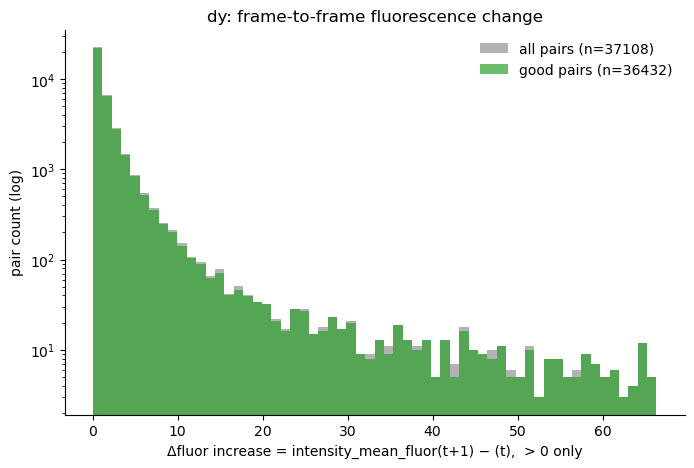

In [100]:
from mmtrack.track_displacement import (
    plot_dy_histogram, plot_dfluor_histogram, plot_dy_vs_dfluor,
)

# plot_* name their files f'{label}_delta_y_hist' etc. MIN_TRACK_FRAMES is excluded from
# the label because it does not apply to pairs.
DY_LABEL = 'dy' + scope_suffix(GENE, EXPERIMENTS, FOVS)

print(plot_dy_histogram(pairs, DY_BOUNDS, DY_LABEL, FIG_DIR,
                        close=False, units=DY_UNITS))
print(plot_dfluor_histogram(pairs, good, DY_LABEL, FIG_DIR, close=False))

### Merging the pairs back onto the cell table

`time_frame` (= `frame_from`) attributes each pair to the frame it starts from, so the table
left-merges 1:1 onto `all_data`. Every row keeps its full identity — `experiment_name`, `FOV`,
`trench_id`, `track_id` — so any pair traces back to one cell in one kymograph.

Each track's **last** frame has no successor and so no pair, which is exactly the 12,542-row
shortfall below: one per track.

In [101]:
MERGE_KEY  = ['experiment_name', 'FOV', 'trench_id', 'track_id', 'time_frame']
DELTA_COLS = ['delta_y', 'cell_length', 'delta_y_cell_lengths', 'delta_fluor',
              'is_jump', 'fluor_zscore', 'is_significant']

merged = all_data.merge(pairs_all[MERGE_KEY + DELTA_COLS], on=MERGE_KEY, how='left')

assert len(merged) == len(all_data), 'merge changed the row count -- duplicate join keys'
n_with = int(merged['delta_y'].notna().sum())
print(f'{len(merged):,} rows  |  {n_with:,} carry a Δ  |  '
      f'{len(merged) - n_with:,} without, = one per track (the final frame)')
print(f'tracks in all_data: {len(all_data[CELL_KEY].drop_duplicates()):,}')
print()
print(merged.loc[merged.is_jump == True,
                 CELL_KEY + ['time_frame', 'delta_y', 'cell_length',
                             'delta_y_cell_lengths']]
      .head(5).to_string(index=False))

89,041 rows  |  76,499 carry a Δ  |  12,542 without, = one per track (the final frame)
tracks in all_data: 12,542

     experiment_name FOV trench_id  track_id  time_frame     delta_y  cell_length  delta_y_cell_lengths
CL008_giTG068_072925 003       312         1           0   53.470401    40.230865              1.329089
CL008_giTG068_072925 003       312         2           1 -142.271627    47.335885             -3.005577
CL008_giTG068_072925 003       312         2           2  -59.991795    36.390708             -1.648547
CL008_giTG068_072925 003       312         4           2  -68.471192    26.751012             -2.559574
CL008_giTG068_072925 003       312         6           5   24.525746    23.925426              1.025091


---
# Average fluorescence per gene

`intensity_mean_fluor` is the per-cell mean on the **background-subtracted** fluorescence
channel (stage 2 writes the `subtracted_*` TIFFs), so it is already offset-corrected.

Two figures: raw, and divided by each experiment's `fluor_exposure_ms`. Exposure is a real
confounder here — every gene except murQ spans two or three settings (150 / 250 / 450 / 500 ms),
so the raw bars are not directly comparable across genes.

**These two plots deliberately ignore `GENE`** (a per-gene bar chart scoped to one gene is a
single bar). `EXPERIMENTS`, `FOVS` and `MIN_TRACK_FRAMES` still apply.

Each gene gets two bars — the grand mean over every cell×frame row, and the mean of the
per-experiment means. They differ whenever one acquisition dominates a gene's row count; baeS
is the extreme case. Dots are the individual experiment means, coloured by exposure. The y-axis
is log: the range spans ~150×.

In [102]:
FLUOR_COL = 'intensity_mean_fluor'
EXPOSURE_COL = 'fluor_exposure_ms'

# Gene axis always populated -> ignore GENE, keep the other filters.
fluor_df = scope(all_data, gene=None, experiments=EXPERIMENTS, fovs=FOVS,
                 min_frames=MIN_TRACK_FRAMES)
fluor_df = fluor_df.assign(fluor_per_ms=fluor_df[FLUOR_COL] / fluor_df[EXPOSURE_COL])


def fluor_by_gene(df, value_col=FLUOR_COL):
    """Per gene: grand mean over cell-frames, mean of per-experiment means, and the
    per-experiment values those are built from."""
    per_exp = (df.groupby(['gene', 'experiment_name'])
                 .agg(mean=(value_col, 'mean'), n_rows=(value_col, 'size'),
                      exposure_ms=(EXPOSURE_COL, 'first'))
                 .reset_index())
    summary = pd.DataFrame({
        'n_experiments':     per_exp.groupby('gene').size(),
        'n_rows':            df.groupby('gene')[value_col].size(),
        'grand_mean':        df.groupby('gene')[value_col].mean(),
        'mean_of_exp_means': per_exp.groupby('gene')['mean'].mean(),
        'min_exp_mean':      per_exp.groupby('gene')['mean'].min(),
        'max_exp_mean':      per_exp.groupby('gene')['mean'].max(),
    })
    summary['fold_range'] = (summary['max_exp_mean'] / summary['min_exp_mean'])
    summary = summary.sort_values('mean_of_exp_means', ascending=False)
    return summary, per_exp


# One colour per exposure setting, shared by both figures. tab10 slots chosen to avoid
# the two bar colours below. Exposure is ordinal (150 < 250 < 450 < 500) and a categorical
# palette cannot show that -- the legend is sorted ascending to carry the ordering instead.
EXPOSURES = sorted(fluor_df[EXPOSURE_COL].unique())
_EXPOSURE_CYCLE = ['#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#bcbd22']
EXPOSURE_COLOR = {e: _EXPOSURE_CYCLE[i % len(_EXPOSURE_CYCLE)]
                  for i, e in enumerate(EXPOSURES)}


def plot_fluor_bars(summary, per_exp, vlabel, title, name, seed=0):
    genes = list(summary.index)
    x = np.arange(len(genes))
    fig, ax = plt.subplots(figsize=(1.05 * len(genes) + 4, 5.5))

    ax.bar(x - 0.21, summary['grand_mean'], width=0.4, color='#1f77b4',
           alpha=0.85, label='grand mean (per cell-frame)')
    ax.bar(x + 0.21, summary['mean_of_exp_means'], width=0.4, color='#ff7f0e',
           alpha=0.85, label='mean of experiment means')

    # One dot per experiment. Deterministic jitter so the figure is reproducible.
    rng = np.random.default_rng(seed)
    seen = set()
    for xi, gene in enumerate(genes):
        sub = per_exp[per_exp['gene'] == gene]
        jitter = rng.uniform(-0.16, 0.16, len(sub))
        for (_, row), dx in zip(sub.iterrows(), jitter):
            expo = row['exposure_ms']
            ax.scatter(xi + dx, row['mean'], s=26, zorder=3,
                       color=EXPOSURE_COLOR[expo], edgecolor='0.25', linewidth=0.5,
                       label=f'{expo:g} ms' if expo not in seen else None)
            seen.add(expo)

    ax.set_yscale('log')          # the log scale follows the VALUE axis
    ax.set_xticks(x, genes)       # genes on x
    ax.set_ylabel(vlabel)
    ax.set_title(f'{title}\n{scope_label(None, EXPERIMENTS, FOVS, MIN_TRACK_FRAMES)}',
                 loc='left')
    ax.legend(frameon=False, fontsize=8, ncol=2, title='bars / exposure',
              title_fontsize=8)
    _style(ax)
    fig.tight_layout()
    print(_save(fig, name))
    return fig

### Figure 4 — raw mean fluorescence per gene

mean intensity_mean_fluor per gene  [all genes]

      n_experiments  n_rows  grand_mean  mean_of_exp_means  min_exp_mean  max_exp_mean  fold_range
gene                                                                                              
hupA              2    1542     606.472            609.335       601.536       617.133       1.026
baeS              3   18255      24.314             90.380        13.507       237.782      17.604
mazF              3    3240      54.869             66.854        40.593        80.120       1.974
chpS              3   10113      17.635             17.163         1.530        27.289      17.830
gldA              3    5871      10.909             11.089        10.479        11.503       1.098
alkA              6    8238      10.239              9.781         1.378        16.736      12.148
murQ              1    1776       8.210              8.210         8.210         8.210       1.000
gfcE              4   13915       6.899              6.012  

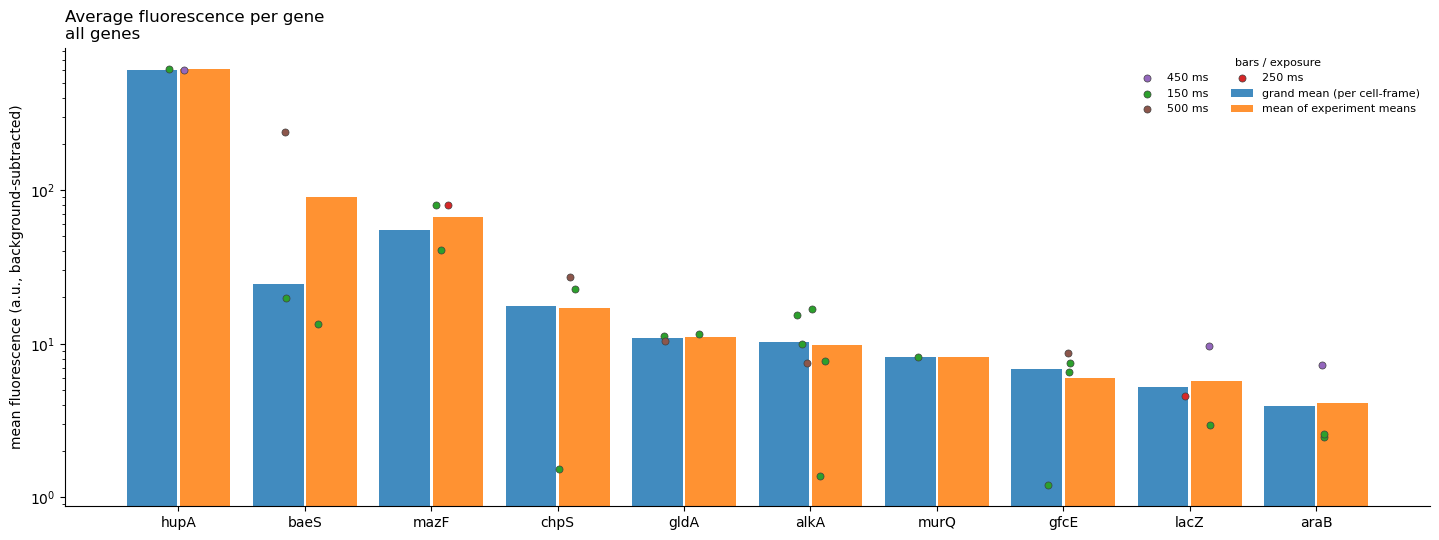

In [103]:
raw_summary, raw_per_exp = fluor_by_gene(fluor_df, FLUOR_COL)
print(f'mean {FLUOR_COL} per gene  [{scope_label(None, EXPERIMENTS, FOVS, MIN_TRACK_FRAMES)}]\n')
print(raw_summary.round(3).to_string())

plot_fluor_bars(raw_summary, raw_per_exp,
                vlabel='mean fluorescence (a.u., background-subtracted)',
                title='Average fluorescence per gene',
                name=f'fluor_per_gene{SUFFIX}');

### Figure 5 — exposure-normalised

mean fluorescence per ms of exposure  [all genes]

      n_experiments  n_rows  grand_mean  mean_of_exp_means  min_exp_mean  max_exp_mean  fold_range
gene                                                                                              
hupA              2    1542      2.2157             2.7255        1.3367        4.1142      3.0778
mazF              3    3240      0.3434             0.3745        0.2706        0.5323      1.9671
baeS              3   18255      0.1108             0.2326        0.0900        0.4756      5.2813
chpS              3   10113      0.0575             0.0720        0.0102        0.1511     14.8109
alkA              6    8238      0.0593             0.0594        0.0092        0.1116     12.1475
gldA              3    5871      0.0480             0.0576        0.0210        0.0767      3.6592
murQ              1    1776      0.0547             0.0547        0.0547        0.0547      1.0000
gfcE              4   13915      0.0273             0.0299

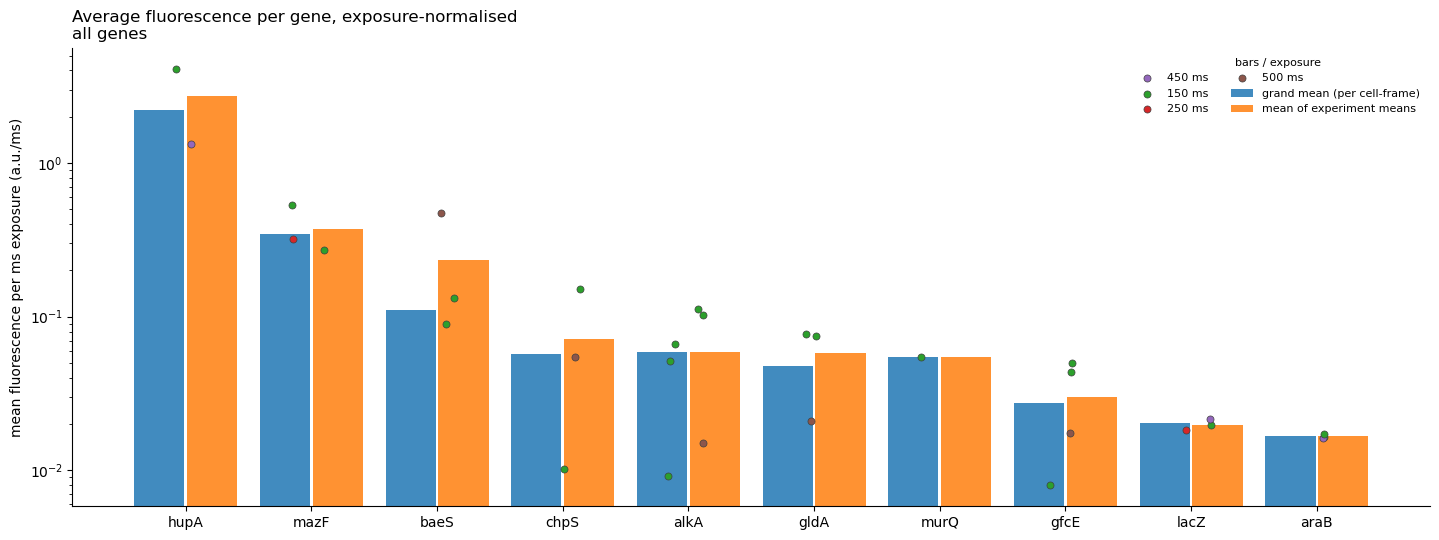

In [104]:
norm_summary, norm_per_exp = fluor_by_gene(fluor_df, 'fluor_per_ms')
print(f'mean fluorescence per ms of exposure  '
      f'[{scope_label(None, EXPERIMENTS, FOVS, MIN_TRACK_FRAMES)}]\n')
print(norm_summary.round(4).to_string())

# Did normalising reorder the genes?
ranks = pd.DataFrame({
    'raw_rank': raw_summary['mean_of_exp_means'].rank(ascending=False).astype(int),
    'per_ms_rank': norm_summary['mean_of_exp_means'].rank(ascending=False).astype(int),
})
ranks['shift'] = ranks['raw_rank'] - ranks['per_ms_rank']
print('\nrank change from normalising (0 = unchanged):')
print(ranks.sort_values('raw_rank').to_string())

plot_fluor_bars(norm_summary, norm_per_exp,
                vlabel='mean fluorescence per ms exposure (a.u./ms)',
                title='Average fluorescence per gene, exposure-normalised',
                name=f'fluor_per_gene_per_ms{SUFFIX}');

---
# Single-trench inspection

Everything above is pooled. These two functions drop into one trench — the step between spotting
an odd number in a table and opening `data/kymograph_viewer_080726.html`. Both take
`(experiment_name, FOV, peak_id)`; use Table C to find valid combinations.

**A note on the lookup.** `FOV` and `trench_id` are zero-padded **strings** here (`'015'`,
`'228'`) so they join to `experiment_metadata` and the viewer's card ids. The version of
`plot_track_fluorescence` in the older notebook opened with `fov = int(fov)`, which was right
there — a bare `read_csv` gave int64 — but silently matches **nothing** against strings, so every
call would fall through to `WARNING: no rows`. `select_trench` below normalises whatever you pass,
so `('015', 228)` and `(15, '228')` both work.

In [105]:
def select_trench(df, exp, fov, peak_id):
    """Rows for one trench, tolerant of int or str ids.

    FOV is stored zero-padded to 3 chars; trench_id (peak_id) is stored unpadded, so
    str(int(...)) strips any leading zeros the caller supplies.
    """
    return df[(df['experiment_name'] == exp)
              & (df['FOV'] == str(fov).zfill(3))
              & (df['trench_id'] == str(int(peak_id)))]

In [106]:
def plot_track_fluorescence(df, exp, fov, peak_id, cell_id=None,
                            fluor_col='intensity_mean_fluor', save=False):
    """Plot avg fluorescence vs time for each unique cell track in one trench.

    Left panel:  raw time_frame on the x-axis.
    Right panel: time re-zeroed per track (frames since each track's first appearance).

    Args:
        df: per-cell-per-frame DataFrame (e.g. all_data) with columns
            experiment_name, FOV, trench_id, track_id, time_frame, and fluor_col.
        exp: experiment_name (str).
        fov: FOV id (accepts zero-padded str like '015' or int).
        peak_id: trench / peak id (accepts str or int); matches df['trench_id'].
        cell_id: optional track_id (int) of a single lineage to highlight. When given,
            that lineage is drawn boldly and all other tracks are dimmed to gray so it's
            easy to focus on one lineage. The id matches the labels shown in the
            kymograph viewer. When None (default), all tracks are plotted as usual.
        fluor_col: fluorescence column to plot (default 'intensity_mean_fluor').
        save: write the figure to FIG_DIR as well as displaying it.
    """
    sub = select_trench(df, exp, fov, peak_id)

    if sub.empty:
        print(f"WARNING: no rows for experiment={exp!r}, FOV={fov}, trench/peak={peak_id}")
        return

    track_ids = sorted(sub['track_id'].unique())
    # tab20 by position in the sorted track list -- deliberately NOT the pinned tab10 gene
    # palette. This matches build_track_color_map() in generate_kymograph_viewer.py, so a
    # line here is the same colour as that track in the HTML viewer.
    cmap = plt.get_cmap('tab20', len(track_ids))
    track_colors = {tid: cmap(i) for i, tid in enumerate(track_ids)}

    # Validate the requested highlight id; fall back to normal rendering if not found.
    if cell_id is not None:
        cell_id = int(cell_id)
        if cell_id not in track_ids:
            print(f"WARNING: cell_id={cell_id} not found in FOV {fov}, trench {peak_id}. "
                  f"Available track_ids: {track_ids}")
            cell_id = None

    fig, (ax_raw, ax_elapsed) = plt.subplots(1, 2, figsize=(14, 5))

    for tid in track_ids:
        g = sub[sub['track_id'] == tid].sort_values('time_frame')
        elapsed = g['time_frame'] - g['time_frame'].min()

        if cell_id is None:
            # Default: every track in its own color.
            kw = dict(color=track_colors[tid], label=tid)
        elif tid == cell_id:
            # Highlighted lineage: bold, opaque, drawn on top.
            kw = dict(color=track_colors[tid], label=tid, linewidth=2.5, alpha=1.0, zorder=3)
        else:
            # Everything else: dimmed to gray in the background.
            kw = dict(color='lightgray', linewidth=1.0, alpha=0.4, zorder=1)

        ax_raw.plot(g['time_frame'], g[fluor_col], **kw)
        ax_elapsed.plot(elapsed, g[fluor_col], **kw)

    highlight_note = f' (cell {cell_id})' if cell_id is not None else ''
    ax_raw.set_xlabel('Time frame')
    ax_raw.set_ylabel('Mean fluorescence intensity')
    ax_raw.set_title(f'{exp}\nFOV {fov}, trench {peak_id} - raw time{highlight_note}')

    ax_elapsed.set_xlabel('Frames since track start')
    ax_elapsed.set_ylabel('Mean fluorescence intensity')
    ax_elapsed.set_title(f'{exp}\nFOV {fov}, trench {peak_id} - time elapsed per track{highlight_note}')

    for ax in (ax_raw, ax_elapsed):
        _style(ax)

    # Legend: show just the highlighted track when one is set, otherwise the usual
    # all-tracks legend when the count is small enough to be readable.
    if cell_id is not None:
        ax_raw.legend(title='track_id', fontsize=8)
    elif len(track_ids) <= 20:
        ax_raw.legend(title='track_id', fontsize=8, ncol=2)

    fig.tight_layout()
    if save:
        print(_save(fig, f'track_fluor_{exp}_{str(fov).zfill(3)}_{int(peak_id)}'))
    return fig

In [107]:
from mmtrack.track_displacement import C_MAIN, C_ALL   # same tab10 as the pooled figures


def plot_trench_dy_dfluor(pairs, exp, fov, peak_id, bins=40, cell_id=None,
                          top_n=10, save=False):
    """Δy and Δfluor for one trench, highlighted against its whole experiment.

    Companion to plot_track_fluorescence, same (exp, fov, peak_id) arguments but reading
    the pair table rather than the cell table.

    The grey histogram is every pair in the experiment; the trench is drawn on top of it,
    so you can see at a glance whether this trench moves or changes brightness unusually
    for its experiment. The trench is ~9% of the experiment's pairs and its rarest bins
    hold a single pair, so the y-axis is log -- on a linear axis the trench peak is only
    10-14% of the axis height and the tails are invisible.

    UNITS. delta_fluor = intensity_mean_fluor(t+1) - intensity_mean_fluor(t), where
    intensity_mean_fluor is the mean pixel value inside the cell mask on the
    BACKGROUND-SUBTRACTED fluor channel. So it is arbitrary camera units (a.u.) per
    FRAME: not exposure-normalised, and not per-minute. Comparable within an experiment,
    not across experiments that differ in exposure or frame interval.

    Args:
        pairs: pair-level DataFrame (pairs_all).
        cell_id: optional track_id; narrows the highlight to one track, backdrop unchanged.
        top_n: print this many pairs with the largest fluorescence INCREASE (0 = skip).
        save: write the figure to FIG_DIR as well as displaying it.
    """
    backdrop = pairs[pairs['experiment_name'] == exp]
    if backdrop.empty:
        print(f"WARNING: no pairs for experiment={exp!r}")
        return

    sub = select_trench(pairs, exp, fov, peak_id)
    if sub.empty:
        print(f"WARNING: no pairs for experiment={exp!r}, FOV={fov}, trench/peak={peak_id}")
        return

    if cell_id is not None:
        cell_id = int(cell_id)
        if cell_id not in set(sub['track_id']):
            print(f"WARNING: cell_id={cell_id} has no pairs in FOV {fov}, trench {peak_id}. "
                  f"Available track_ids: {sorted(sub['track_id'].unique())}")
            cell_id = None
        else:
            sub = sub[sub['track_id'] == cell_id]

    mins = int(sub['minutes_per_frame'].iloc[0])
    note = f' | cell {cell_id}' if cell_id is not None else ''
    print(f'{exp} FOV {str(fov).zfill(3)} trench {int(peak_id)}{note}: '
          f'{len(sub)} pairs | {sub.track_id.nunique()} tracks | '
          f'median cell length {sub.cell_length.median():.1f} px  '
          f'(experiment backdrop: {len(backdrop)} pairs)')

    fig, (ax_dy, ax_df) = plt.subplots(1, 2, figsize=(14, 4.5))

    panels = ((ax_dy, 'delta_y',
               'Δy = centroid_y(t+1) − centroid_y(t)  [px]'),
              (ax_df, 'delta_fluor',
               'Δfluor = fluor(t+1) − fluor(t)  [a.u. per frame, bg-subtracted]'))

    for ax, col, xlabel in panels:
        # Bin edges from the EXPERIMENT's robust range: a handful of extreme pairs would
        # otherwise flatten every bin that matters.
        lo, hi = np.nanpercentile(backdrop[col].dropna(), [0.5, 99.5])
        edges = np.linspace(lo, hi, bins + 1)

        ax.hist(backdrop[col].dropna(), bins=edges, color=C_ALL, alpha=0.55,
                label=f'experiment (n={len(backdrop):,})')
        ax.hist(sub[col].dropna(), bins=edges, color=C_MAIN, alpha=0.95,
                label=f'this trench (n={len(sub):,})')

        off = int(((sub[col] < lo) | (sub[col] > hi)).sum())
        if off:
            # Say so rather than letting the clipped range imply the trench has no tail.
            ax.plot([], [], ' ', label=f'{off} trench pair(s) off-axis')

        ax.set_yscale('log')          # the trench is ~9% of the backdrop; linear hides it
        ax.set_xlabel(xlabel)
        ax.set_ylabel('pair count (log)')
        ax.legend(frameon=False, fontsize=8)
        _style(ax)

    ax_dy.set_title(f'{exp}\nFOV {str(fov).zfill(3)}, trench {int(peak_id)}{note} — Δy',
                    fontsize=10)
    ax_df.set_title(f'{exp}\nFOV {str(fov).zfill(3)}, trench {int(peak_id)}{note} — Δfluor',
                    fontsize=10)

    fig.tight_layout()
    if save:
        print(_save(fig, f'trench_dy_dfluor_{exp}_{str(fov).zfill(3)}_{int(peak_id)}'))

    if top_n:
        cols = ['track_id', 'frame_from', 'frame_to', 'time_min_from',
                'fluor_from', 'fluor_to', 'delta_fluor',
                'delta_y', 'delta_y_cell_lengths', 'predicted_lineage']
        top = (sub[sub['delta_fluor'] > 0]
               .sort_values('delta_fluor', ascending=False)
               .head(top_n)[cols])
        print(f'\ntop {len(top)} pairs by fluorescence INCREASE  '
              f'(a.u. per frame, {mins} min/frame, not exposure-normalised)')
        # delta_y is kept alongside on purpose: a large step next to a large displacement
        # is usually the track moving, not the cell brightening.
        print(top.round(3).to_string(index=False))

    return fig

### Worked example

Change `EX_EXP` / `EX_FOV` / `EX_PEAK` to inspect a different trench — Table C above lists every
valid `(gene, experiment, FOV, peak_ids)` combination. Set `cell_id=` on either function to
follow one lineage; the ids match the "cell N" entries in the kymograph viewer's dropdown.

DUMM_giTG059_060_061125 FOV 008 trench 1488: 333 pairs | 79 tracks | median cell length 37.1 px  (experiment backdrop: 601 pairs)

top 10 pairs by fluorescence INCREASE  (a.u. per frame, 10 min/frame, not exposure-normalised)
 track_id  frame_from  frame_to  time_min_from  fluor_from  fluor_to  delta_fluor  delta_y  delta_y_cell_lengths predicted_lineage
        8          11        12            110       9.850    15.855        6.005   -1.014                -0.029               7.1
        3           4         5             40       1.628     7.314        5.687   11.275                 0.293                 3
       44          52        53            520       3.818     8.473        4.655  -13.829                -0.334           3.2.1.1
       89          79        80            790       5.486     9.520        4.034    6.740                 0.151                25
       11          18        19            180       3.618     7.390        3.772  -14.832                -0.480       

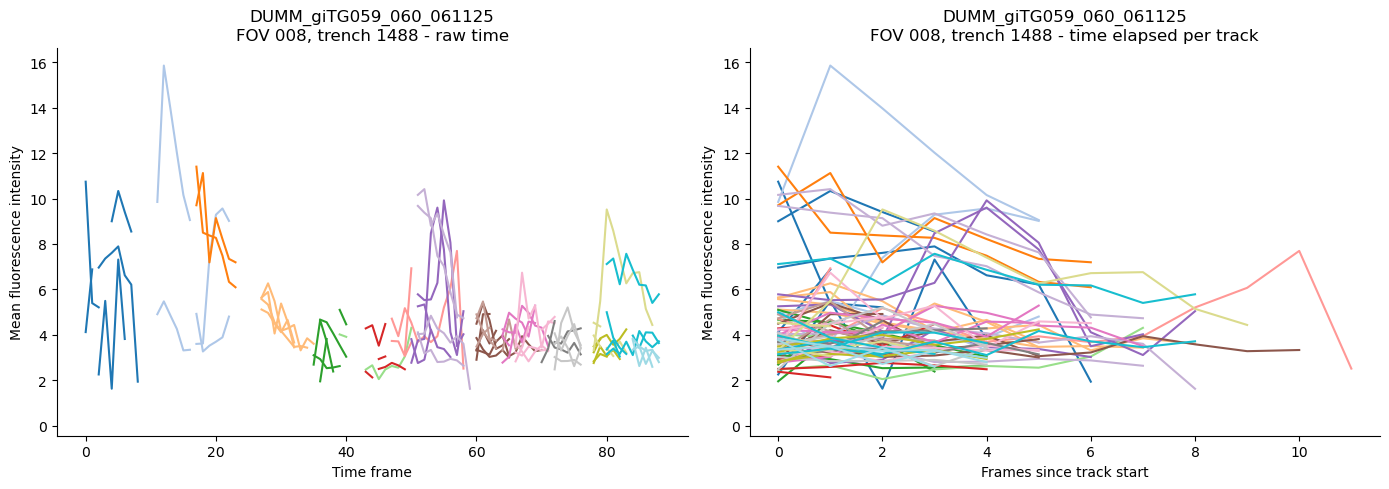

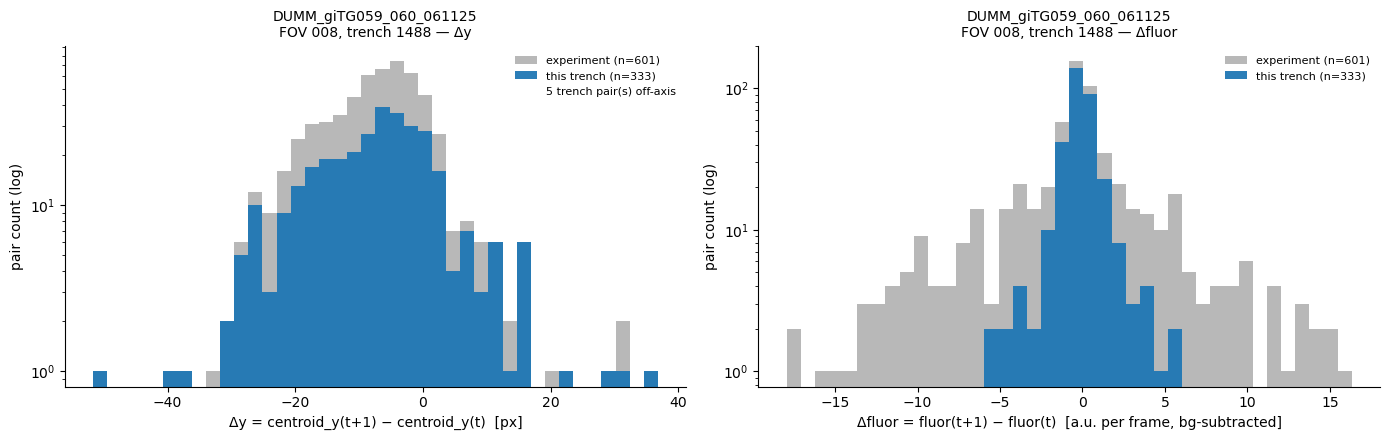

In [111]:
EX_EXP, EX_FOV, EX_PEAK = 'DUMM_giTG059_060_061125', '008', '1488'

plot_track_fluorescence(all_data, EX_EXP, EX_FOV, EX_PEAK);
plot_trench_dy_dfluor(pairs_all, EX_EXP, EX_FOV, EX_PEAK);